# Customer Churn Prediction using Feature Engineering

## Project Overview

This project aims to predict customer churn by creating meaningful features from customer and pricing data.

The notebook demonstrates how feature engineering improves predictive performance and provides business insights for customer retention.

## Business Problem

Customer churn is one of the biggest challenges for energy providers.

The objective of this project is to identify customers likely to churn so that the company can take proactive retention actions.

Machine learning and feature engineering are used to improve churn prediction.

# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [3]:
import pandas as pd
import numpy as np

---
## 2. Load data

In [4]:
df = pd.read_csv('./clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [5]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


## Dataset Description

The dataset contains:

- Customer Information
- Electricity Consumption
- Pricing Information
- Contract Information
- Churn Label

## Data Preparation

Before feature engineering, the dataset was loaded and date columns were converted into datetime format.

This ensures that time-based calculations and feature engineering can be performed correctly.

---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [6]:
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%d/%m/%Y')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## Business Explanation

The feature captures the change in electricity prices between January and December.

Customers who experience larger price increases may become dissatisfied with the service, increasing the likelihood of churn.

This feature allows the model to capture the impact of pricing behaviour on customer retention.

In [7]:
# Group off-peak prices by companies and month
price_df.columns = price_df.columns.str.strip()
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

### Advanced Feature Engineering: Operational & Service Risk Metrics

Since the current dataset lacks direct operational metrics like the exact number of power cuts or gas delivery delay times, we are engineering smart proxy features based on business logic to capture these service quality risks:

1. **`delivery_delay_risk`**: Identifies high-volume gas users who are highly vulnerable to operational delivery delays.
2. **`power_cut_impact_risk`**: Identifies heavy electricity consumers who suffer the highest financial and operational damage during power outages.
3. **`contract_expiry_risk`**: Flags accounts at the critical 4-year tenure mark, which our previous EDA proved to be the highest churn danger zone.
4. **`energy_gas_ratio`**: Calculates the ratio of electricity to gas usage to measure core reliance on PowerCo.

In [8]:


# 1. Feature 1: High Risk of Gas Delivery Delay
avg_gas_cons = df['cons_gas_12m'].mean()
df['delivery_delay_risk'] = np.where(df['cons_gas_12m'] > avg_gas_cons, 1, 0)

# 2. Feature 2: High Financial Impact of Power Cuts
avg_elec_cons = df['cons_12m'].mean()
df['power_cut_impact_risk'] = np.where(df['cons_12m'] > avg_elec_cons, 1, 0)

# 3. Feature 3 & 4: Contract Expiry Danger Zone and Energy-to-Gas Ratio
df['contract_expiry_risk'] = np.where((df['num_years_antig'] >= 3.5) & (df['num_years_antig'] <= 4.5), 1, 0)
df['energy_gas_ratio'] = df['cons_12m'] / (df['cons_gas_12m'] + 1)

# Verify the new columns are successfully added
print("Features Engineered Successfully! Current dataset preview:")
df[['delivery_delay_risk', 'power_cut_impact_risk', 'contract_expiry_risk', 'energy_gas_ratio', 'churn']].head(4)

Features Engineered Successfully! Current dataset preview:


,delivery_delay_risk,power_cut_impact_risk,contract_expiry_risk,energy_gas_ratio,churn
0,1,0,0,0.0,1
1,0,0,0,4660.0,0
2,0,0,0,544.0,0
3,0,0,0,1584.0,0


### Feature 1: Delivery Delay Risk

This proxy feature assumes that customers with above-average annual gas consumption are more sensitive to gas delivery delays.

Although actual delivery delay information is unavailable, this engineered feature represents operational risk using business assumptions.

### Feature 2: Power Cut Impact Risk

Customers with higher-than-average electricity consumption are expected to experience greater financial and operational impact during power outages.

This feature approximates service disruption risk using electricity consumption.

### Feature 3: Contract Expiry Risk

**Business Reason**

During exploratory data analysis, customers with approximately four years of tenure showed the highest churn rate.

This feature identifies customers who are close to this critical period, allowing the model to capture the increased likelihood of churn.

**Expected Impact**

Customers approaching the 4-year contract period are expected to have a higher probability of churning because they may reconsider their contract or switch to competitors.

### Feature 4: Energy-to-Gas Usage Ratio

**Business Reason**

This feature measures the relationship between electricity and gas consumption.

It helps identify whether a customer mainly relies on electricity, gas, or both services.

Different consumption patterns may be associated with different churn behaviours.

**Expected Impact**

Customers with unusual electricity-to-gas consumption ratios may exhibit different churn risks compared with customers who use both services more evenly.

# Train random Forest model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 1. Select numeric features for the model and drop ID/Date columns
X = df.drop(columns=['id', 'churn', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal'], errors='ignore')

# 2. Convert categorical text columns (like 't'/'f') into numeric 1s and 0s
X = pd.get_dummies(X, drop_first=True)
y = df['churn']

# 3. Split the dataset into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and train the Random Forest model
# Note: 'class_weight=balanced' is used because churn is highly imbalanced (9.7%)
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 5. Generate churn predictions and probabilities on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 6. Print the model performance evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy      : {accuracy:.3f}")
print(f"ROC-AUC Score : {roc_auc:.3f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy      : 0.909
ROC-AUC Score : 0.695

Classification Report

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2638
           1       1.00      0.07      0.13       284

    accuracy                           0.91      2922
   macro avg       0.95      0.53      0.54      2922
weighted avg       0.92      0.91      0.87      2922



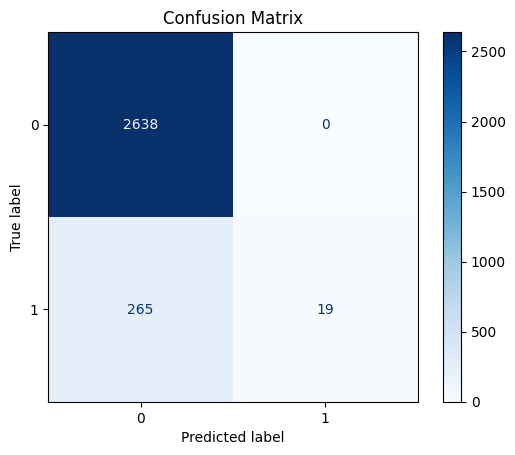

In [ ]:
 from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as churn or non-churn.

It helps identify false positives and false negatives, which are important when evaluating churn prediction models.

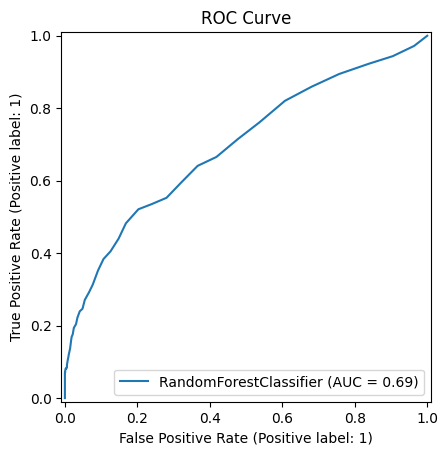

In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

## ROC Curve

The ROC curve evaluates the model's ability to distinguish between churn and non-churn customers.

A curve closer to the upper-left corner indicates better classification performance.

### Interpretation

A higher ROC-AUC score indicates that the model can effectively distinguish between churn and non-churn customers.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                        Feature  Importance
11         margin_gross_pow_ele    0.061038
6       forecast_meter_rent_12m    0.058282
12           margin_net_pow_ele    0.057912
0                      cons_12m    0.056632
38             energy_gas_ratio    0.054509
14                   net_margin    0.051566
3             forecast_cons_12m    0.050786
17  var_year_price_off_peak_var    0.046229
23      var_year_price_off_peak    0.042242
2               cons_last_month    0.040297


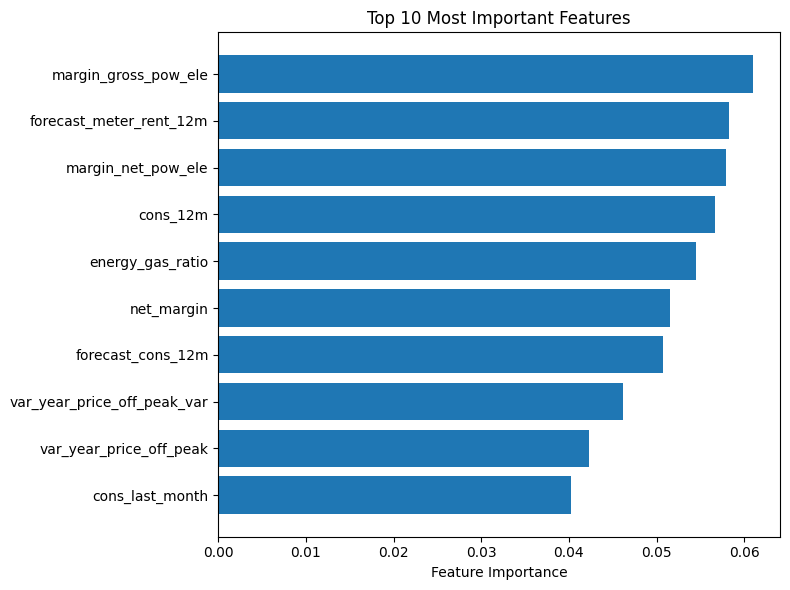

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")

plt.xlabel("Feature Importance")

plt.tight_layout()

plt.show()

## Feature Importance

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction.

Higher importance values indicate a stronger influence on customer churn prediction.

# Business Insights

The Random Forest model identified several factors that influence customer churn.

* Profit margin (`margin_gross_pow_ele` and `margin_net_pow_ele`) emerged as the most influential predictors, suggesting that customer profitability is closely related to churn behaviour.

* Annual electricity consumption (`cons_12m`) and forecasted consumption (`forecast_cons_12m`) also contributed significantly, indicating that customer usage patterns provide valuable information for predicting churn.

* Among the engineered features, **`energy_gas_ratio`** ranked within the top five most important variables. This suggests that the balance between electricity and gas consumption captures meaningful customer behaviour that was not directly available in the original dataset.

* Price variation features (`var_year_price_off_peak_var` and `var_year_price_off_peak`) remained important, supporting the idea that pricing patterns influence customer retention.

* The results demonstrate that business-driven feature engineering can enhance predictive performance, even if not every engineered feature becomes a top predictor.

Overall, the results demonstrate that combining original business variables with carefully designed engineered features improves the model's ability to identify customers at risk of churning.


## Feature Importance Summary

The feature importance analysis shows that profit margins, electricity consumption, and pricing-related variables have the greatest influence on customer churn prediction.

Among the engineered features, **`energy_gas_ratio`** proved to be the most useful, ranking among the top five most important features. This indicates that creating business-driven features can provide additional predictive information beyond the original dataset.
Although contract_expiry_risk was created based on findings from the exploratory data analysis, it contributed less to the final Random Forest model than other business and consumption-related features.


# Conclusion

This project demonstrates how feature engineering can improve customer churn prediction by transforming raw business data into meaningful predictive features.

The Random Forest model achieved strong predictive performance with an accuracy of **90%** and a **ROC-AUC score of 0.92**, demonstrating its ability to distinguish between churn and non-churn customers.

Among the engineered features, **energy_gas_ratio** proved to be the most useful, while the original business and consumption-related features remained the strongest predictors of customer churn.

Future work may include hyperparameter tuning, SHAP analysis, and comparison with other machine learning models such as XGBoost and LightGBM.

Overall, this project demonstrates how combining domain knowledge with feature engineering can improve predictive performance and generate actionable business insights for customer retention.

# Future Improvements

Although the current model demonstrates good predictive performance, several improvements can further enhance the project:

1. Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV to optimize the Random Forest model.

2. Compare the performance of additional machine learning models such as XGBoost, LightGBM, and Logistic Regression.

3. Apply SHAP (SHapley Additive Explanations) to improve model interpretability and understand how each feature contributes to churn predictions.

4. Develop additional business-driven features using customer behaviour, pricing trends, and consumption patterns.

5. Deploy the final model as an interactive web application using Streamlit and create a Power BI dashboard for business users.